In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.io import loadmat
from imckd import imckd


In [2]:
data=loadmat('../../数据集/CRWU/12k Drive End Bearing Fault Data/Ball/0014/B014_0.mat')
data=data['X185_DE_time'].flatten()
data=data[10000:10000+2*12000]

In [3]:
def get_envelope(data,fs):
    N=len(data)
    fs=fs
    t=np.arange(N)/fs
    ff=np.arange(0,fs,fs/N)
    analytic_data=hilbert(data,N) #hir变换
    raw_envelope=np.abs(analytic_data) #取模
    envelope_x = raw_envelope - np.mean(raw_envelope) #去均值
    fft_val=np.fft.fft(envelope_x,N) #傅里叶变换
    magnitude = np.abs(fft_val) #取模
    envelope_spec_x = magnitude * 2.0 / fs #振幅归一化
    plt.plot(ff,envelope_spec_x)
    plt.xlim(0,200)


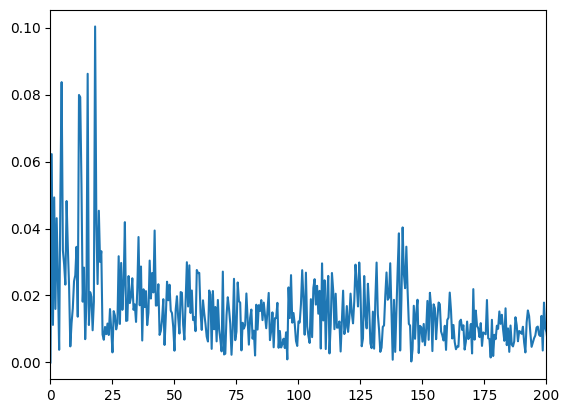

In [4]:
data=loadmat('../../数据集/CRWU/12k Drive End Bearing Fault Data/Ball/0014/B014_0.mat')
data=data['X185_DE_time'].flatten()
data=data[10000:10000+2*12000]
get_envelope(data,12000)

In [5]:
L = 50;                 
T = [];                
M = 1;                 
fs=12000
x=data

y, f, ck_hist  = imckd(fs, x, L, 30, T, M)
t = np.arange(0, 2, 2 / fs)

TypeError: '<=' not supported between instances of 'list' and 'int'

In [ ]:
# 3. 绘图对比
plt.figure(figsize=(12, 8))



plt.subplot(3, 1, 2)
plt.plot(t, y)
plt.title(f"IMCKD Denoised Signal (Detected T={int(fs * 0.05)} samples approx)")
plt.xlim(0, 0.2)

plt.subplot(3, 1, 3)
plt.plot(ck_hist)
plt.title("Correlated Kurtosis Iteration History")
plt.xlabel("Iteration")

plt.tight_layout()
plt.show()